# 06 — Product & Sales Analysis
**Analyze product, category, brand and sales behavior.**


## Objective
- Define the purpose of this stage.
- Record key decisions and assumptions.
- Keep outputs reproducible and easy to trace to the previous stage.


## Planned analysis
- Sales/revenue trends over time
- Product-level performance
- Category-level performance
- Brand-level performance where available
- Purchase-event and session patterns
- Top and low-performing products/categories
- Business-oriented observations


In [ ]:
# Load cleaned event/purchase data from Parquet.
# Build product and sales analytics with PySpark.


## Output
Prepare aggregated tables that can be reused by the dashboard.


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ECommerceCustomerBehaviorAnalytics-06-ProductSales")
    .config("spark.sql.shuffle.partitions", "64")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.2.0


In [3]:
CLEANED_DATA_PATH = "../data/cleaned_ecommerce_oct.parquet"

df = spark.read.parquet(CLEANED_DATA_PATH)

print("Rows:", df.count())
print("Columns:", len(df.columns))

df.printSchema()

Rows: 42380089
Columns: 9
root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)



In [4]:
from pyspark.sql.functions import col

purchase_df = (
    df
    .filter(col("event_type") == "purchase")
    .cache()
)

print("Purchase events:", purchase_df.count())

Purchase events: 742849


In [5]:
from pyspark.sql.functions import sum, avg, count, countDistinct, min, max, round

purchase_summary = (
    purchase_df
    .agg(
        count("*").alias("purchase_events"),
        countDistinct("user_id").alias("purchasing_customers"),
        countDistinct("product_id").alias("unique_products"),
        countDistinct("category_id").alias("unique_categories"),
        countDistinct("brand").alias("unique_brands"),
        round(sum("price"), 2).alias("total_purchase_value"),
        round(avg("price"), 2).alias("average_purchase_value"),
        round(min("price"), 2).alias("minimum_purchase_value"),
        round(max("price"), 2).alias("maximum_purchase_value")
    )
)

purchase_summary.show(truncate=False)

[Stage 8:========================================>                (10 + 4) / 14]

+---------------+--------------------+---------------+-----------------+-------------+--------------------+----------------------+----------------------+----------------------+
|purchase_events|purchasing_customers|unique_products|unique_categories|unique_brands|total_purchase_value|average_purchase_value|minimum_purchase_value|maximum_purchase_value|
+---------------+--------------------+---------------+-----------------+-------------+--------------------+----------------------+----------------------+----------------------+
|742849         |347118              |42241          |567              |1985         |2.2995750227E8      |309.56                |0.77                  |2574.07               |
+---------------+--------------------+---------------+-----------------+-------------+--------------------+----------------------+----------------------+----------------------+



In [6]:
from pyspark.sql.functions import sum, count, countDistinct, round

product_sales = (
    purchase_df
    .groupBy("product_id")
    .agg(
        count("*").alias("purchase_events"),
        countDistinct("user_id").alias("unique_customers"),
        round(sum("price"), 2).alias("total_purchase_value"),
        round(avg("price"), 2).alias("avg_purchase_value")
    )
    .orderBy(col("total_purchase_value").desc())
)

product_sales.show(20, truncate=False)

[Stage 16:=====>                                                   (1 + 9) / 10]

+----------+---------------+----------------+--------------------+------------------+
|product_id|purchase_events|unique_customers|total_purchase_value|avg_purchase_value|
+----------+---------------+----------------+--------------------+------------------+
|1005115   |12543          |8352            |1.240680735E7       |989.14            |
|1005105   |7293           |4794            |1.023924868E7       |1403.98           |
|1004249   |9090           |5538            |6730112.92          |740.39            |
|1005135   |3218           |2163            |5567806.64          |1730.21           |
|1004767   |21806          |14410           |5430723.43          |249.05            |
|1002544   |10549          |6781            |4855702.39          |460.3             |
|1004856   |28944          |19228           |3798956.42          |131.25            |
|1002524   |6633           |4132            |3538299.12          |533.44            |
|1003317   |3220           |2179            |3051294.2

In [7]:
top_products_pd = (
    product_sales
    .limit(20)
    .toPandas()
)

print("Top products table created:", len(top_products_pd), "products")

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Top products table created: 20 products


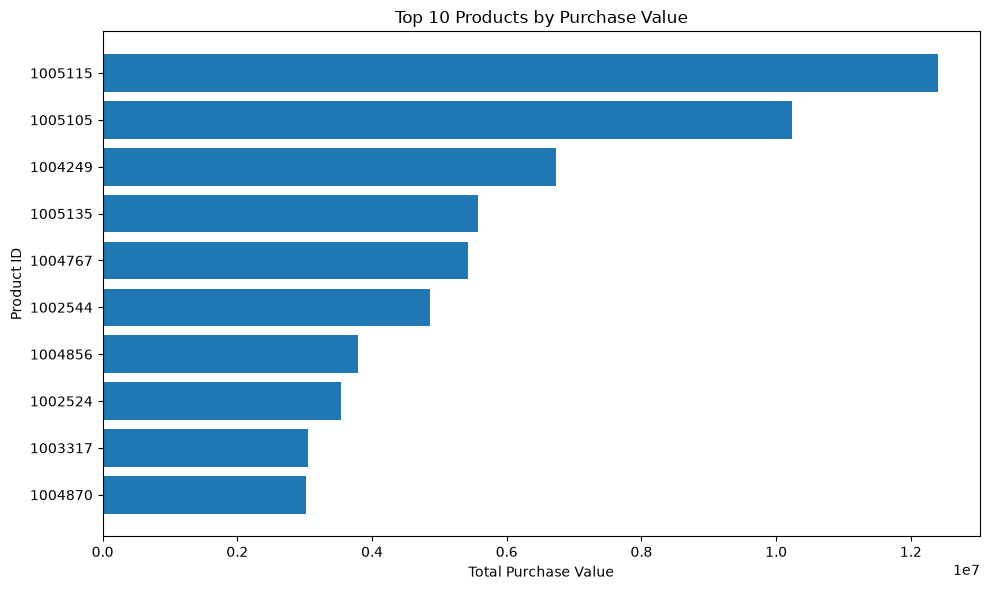

In [8]:
import matplotlib.pyplot as plt

top10_products = top_products_pd.head(10).sort_values(
    "total_purchase_value"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_products["product_id"].astype(str),
    top10_products["total_purchase_value"]
)

plt.xlabel("Total Purchase Value")
plt.ylabel("Product ID")
plt.title("Top 10 Products by Purchase Value")

plt.tight_layout()
plt.show()

In [9]:
category_sales = (
    purchase_df
    .groupBy("category_code")
    .agg(
        count("*").alias("purchase_events"),
        countDistinct("product_id").alias("unique_products"),
        countDistinct("user_id").alias("unique_customers"),
        round(sum("price"), 2).alias("total_purchase_value"),
        round(avg("price"), 2).alias("avg_purchase_value")
    )
    .orderBy(col("total_purchase_value").desc())
)

category_sales.show(20, truncate=False)

[Stage 27:============>                                           (3 + 10) / 14]

+--------------------------------+---------------+---------------+----------------+--------------------+------------------+
|category_code                   |purchase_events|unique_products|unique_customers|total_purchase_value|avg_purchase_value|
+--------------------------------+---------------+---------------+----------------+--------------------+------------------+
|electronics.smartphone          |338018         |924            |160437          |1.5704962337E8      |464.62            |
|unknown                         |173425         |22438          |104897          |2.292493713E7       |132.19            |
|computers.notebook              |15590          |614            |9185            |8979887.25          |576.0             |
|electronics.video.tv            |21565          |387            |13476           |8423407.86          |390.61            |
|electronics.clocks              |17906          |1439           |10746           |4818305.47          |269.09            |
|applian

In [10]:
top_categories_pd = (
    category_sales
    .limit(20)
    .toPandas()
)

print("Top categories table created:", len(top_categories_pd), "categories")

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Top categories table created: 20 categories


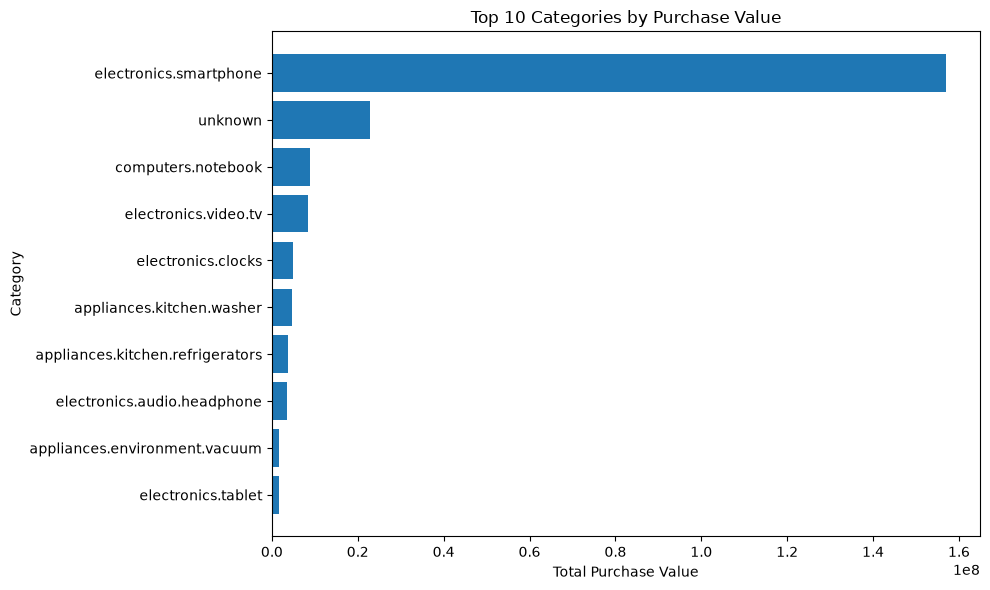

In [11]:
import matplotlib.pyplot as plt

top10_categories = (
    top_categories_pd
    .head(10)
    .sort_values("total_purchase_value")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_categories["category_code"],
    top10_categories["total_purchase_value"]
)

plt.xlabel("Total Purchase Value")
plt.ylabel("Category")
plt.title("Top 10 Categories by Purchase Value")

plt.tight_layout()
plt.show()

In [12]:
brand_sales = (
    purchase_df
    .groupBy("brand")
    .agg(
        count("*").alias("purchase_events"),
        countDistinct("product_id").alias("unique_products"),
        countDistinct("user_id").alias("unique_customers"),
        round(sum("price"), 2).alias("total_purchase_value"),
        round(avg("price"), 2).alias("avg_purchase_value")
    )
    .orderBy(col("total_purchase_value").desc())
)

brand_sales.show(20, truncate=False)

+--------+---------------+---------------+----------------+--------------------+------------------+
|brand   |purchase_events|unique_products|unique_customers|total_purchase_value|avg_purchase_value|
+--------+---------------+---------------+----------------+--------------------+------------------+
|apple   |142873         |394            |65593           |1.1120926882E8      |778.38            |
|samsung |172896         |687            |94073           |4.640753261E7       |268.41            |
|xiaomi  |56616          |474            |35063           |9194033.29          |162.39            |
|unknown |58214          |10381          |38231           |8540601.03          |146.71            |
|huawei  |23501          |104            |15378           |4883421.74          |207.8             |
|acer    |6882           |174            |4352            |3576719.52          |519.72            |
|lg      |8727           |257            |5970            |3387887.96          |388.21            |


In [13]:

top_brands_pd = (
    brand_sales
    .limit(20)
    .toPandas()
)

print("Top brands table created:", len(top_brands_pd), "brands")

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Top brands table created: 20 brands


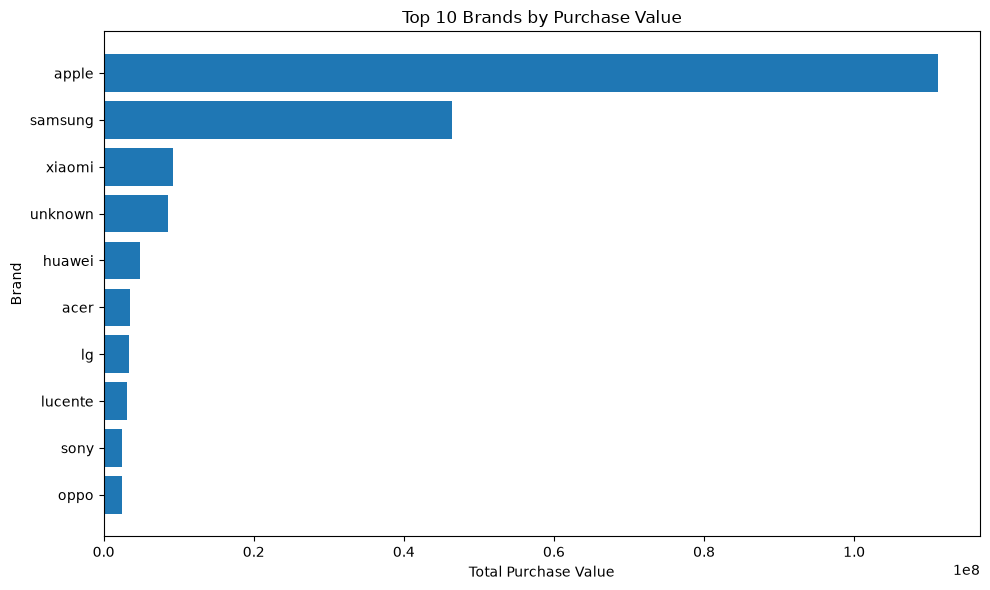

In [14]:
top10_brands = (
    top_brands_pd
    .head(10)
    .sort_values("total_purchase_value")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_brands["brand"],
    top10_brands["total_purchase_value"]
)

plt.xlabel("Total Purchase Value")
plt.ylabel("Brand")
plt.title("Top 10 Brands by Purchase Value")

plt.tight_layout()
plt.show()

In [17]:
from pyspark.sql.functions import (
    to_date,
    count,
    countDistinct,
    sum,
    avg,
    round,
    col
)

daily_sales = (
    purchase_df
    .withColumn("purchase_date", to_date("event_time"))
    .groupBy("purchase_date")
    .agg(
        count("*").alias("purchase_events"),
        countDistinct("user_id").alias("unique_customers"),
        round(sum("price"), 2).alias("total_purchase_value"),
        round(avg("price"), 2).alias("avg_purchase_value")
    )
    .orderBy("purchase_date")
)

daily_sales.show(31, truncate=False)

26/09/30 20:59:25 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:70)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:44)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:34)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(Blo

+-------------+---------------+----------------+--------------------+------------------+
|purchase_date|purchase_events|unique_customers|total_purchase_value|avg_purchase_value|
+-------------+---------------+----------------+--------------------+------------------+
|2019-10-01   |18020          |13253           |5811546.06          |322.51            |
|2019-10-02   |19599          |13926           |6264453.44          |319.63            |
|2019-10-03   |18780          |13415           |6057844.23          |322.57            |
|2019-10-04   |26964          |19078           |8660174.11          |321.18            |
|2019-10-05   |23508          |16769           |7330970.36          |311.85            |
|2019-10-06   |22461          |16239           |6826011.13          |303.91            |
|2019-10-07   |21444          |15363           |6372978.83          |297.19            |
|2019-10-08   |22950          |16585           |6754188.64          |294.3             |
|2019-10-09   |22806 

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


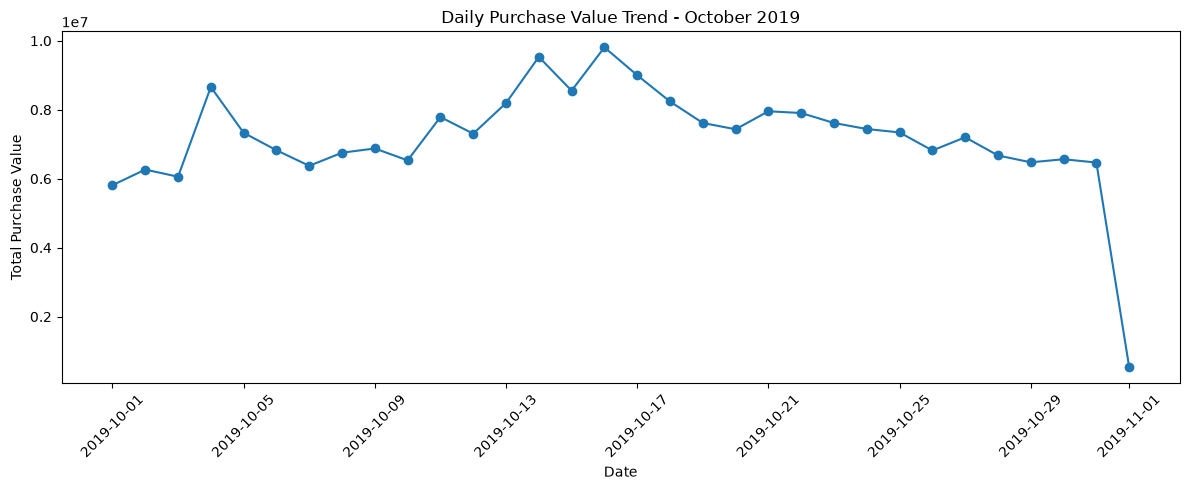

26/09/30 20:59:35 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:70)
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:44)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:34)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(Blo

In [18]:
daily_sales_pd = daily_sales.toPandas()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales_pd["purchase_date"],
    daily_sales_pd["total_purchase_value"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Total Purchase Value")
plt.title("Daily Purchase Value Trend - October 2019")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("ECommerceCustomerBehaviorAnalytics-06-ProductSales")
    .config("spark.sql.shuffle.partitions", "64")
    .getOrCreate()
)

print("Spark version:", spark.version)

CLEANED_DATA_PATH = "../data/cleaned_ecommerce_oct.parquet"

df = spark.read.parquet(CLEANED_DATA_PATH)

purchase_df = (
    df
    .filter(df.event_type == "purchase")
)

print("Cleaned rows:", df.count())
print("Purchase events:", purchase_df.count())

Spark version: 4.2.0
Cleaned rows: 42380089
Purchase events: 742849


In [3]:
from pyspark.sql.functions import to_date, count

daily_purchase_events = (
    purchase_df
    .withColumn("purchase_date", to_date("event_time"))
    .groupBy("purchase_date")
    .agg(
        count("*").alias("purchase_events")
    )
    .orderBy("purchase_date")
)

daily_purchase_events.show(31, truncate=False)

[Stage 14:====================================================>   (13 + 1) / 14]

+-------------+---------------+
|purchase_date|purchase_events|
+-------------+---------------+
|2019-10-01   |18020          |
|2019-10-02   |19599          |
|2019-10-03   |18780          |
|2019-10-04   |26964          |
|2019-10-05   |23508          |
|2019-10-06   |22461          |
|2019-10-07   |21444          |
|2019-10-08   |22950          |
|2019-10-09   |22806          |
|2019-10-10   |21534          |
|2019-10-11   |26381          |
|2019-10-12   |25377          |
|2019-10-13   |29175          |
|2019-10-14   |28756          |
|2019-10-15   |26146          |
|2019-10-16   |31457          |
|2019-10-17   |28266          |
|2019-10-18   |26027          |
|2019-10-19   |24607          |
|2019-10-20   |25075          |
|2019-10-21   |25375          |
|2019-10-22   |25429          |
|2019-10-23   |24664          |
|2019-10-24   |23897          |
|2019-10-25   |24046          |
|2019-10-26   |22520          |
|2019-10-27   |23512          |
|2019-10-28   |21227          |
|2019-10

In [4]:
daily_purchase_events_pd = daily_purchase_events.toPandas()

daily_purchase_events_pd.to_csv(
    "../outputs/tables/daily_purchase_events_oct.csv",
    index=False
)

print("Daily purchase events table saved successfully.")

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Daily purchase events table saved successfully.


In [6]:
from pyspark.sql.functions import (
    col,
    date_format,
    count,
    countDistinct,
    sum,
    avg,
    round,
    when
)

daily_purchase_dow = (
    purchase_df
    .withColumn("day_name", date_format("event_time", "EEEE"))
    .groupBy("day_name")
    .agg(
        count("*").alias("purchase_events"),
        countDistinct("user_id").alias("unique_customers"),
        round(sum("price"), 2).alias("total_purchase_value"),
        round(avg("price"), 2).alias("avg_purchase_value")
    )
    .withColumn(
        "day_order",
        when(col("day_name") == "Sunday", 1)
        .when(col("day_name") == "Monday", 2)
        .when(col("day_name") == "Tuesday", 3)
        .when(col("day_name") == "Wednesday", 4)
        .when(col("day_name") == "Thursday", 5)
        .when(col("day_name") == "Friday", 6)
        .when(col("day_name") == "Saturday", 7)
    )
    .orderBy("day_order")
    .drop("day_order")
)

daily_purchase_dow.show(truncate=False)

[Stage 25:========================================>               (10 + 4) / 14]

+---------+---------------+----------------+--------------------+------------------+
|day_name |purchase_events|unique_customers|total_purchase_value|avg_purchase_value|
+---------+---------------+----------------+--------------------+------------------+
|Sunday   |100223         |67653           |2.965383992E7       |295.88            |
|Monday   |96802          |63375           |3.053596331E7       |315.45            |
|Tuesday  |113096         |74293           |3.549746682E7       |313.87            |
|Wednesday|119201         |77721           |3.713153921E7       |311.5             |
|Thursday |112610         |73470           |3.549913927E7       |315.24            |
|Friday   |104905         |68792           |3.256769027E7       |310.45            |
|Saturday |96012          |64674           |2.907186347E7       |302.79            |
+---------+---------------+----------------+--------------------+------------------+



/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


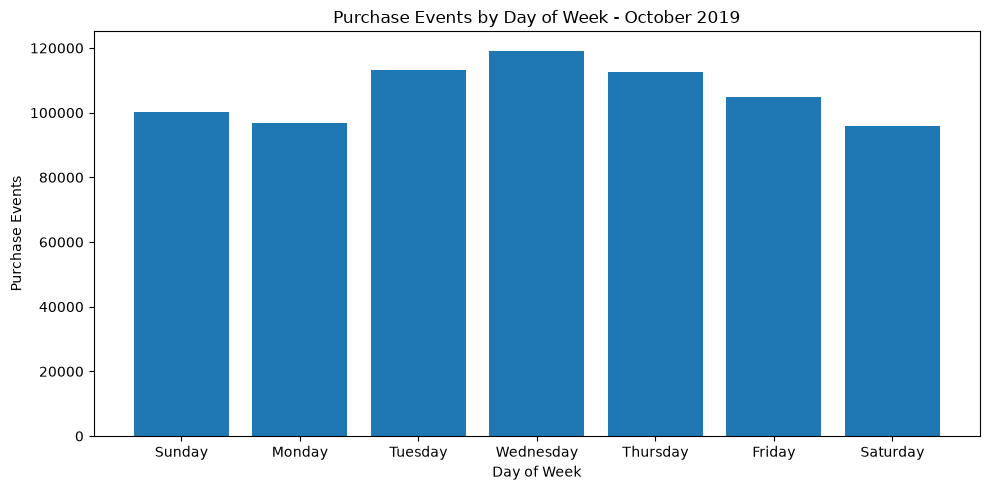

In [8]:
import matplotlib.pyplot as plt

dow_pd = daily_purchase_dow.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    dow_pd["day_name"],
    dow_pd["purchase_events"]
)

plt.xlabel("Day of Week")
plt.ylabel("Purchase Events")
plt.title("Purchase Events by Day of Week - October 2019")

plt.tight_layout()
plt.show()

In [9]:
plt.savefig(
    "../outputs/figures/purchase_events_by_day_of_week.png",
    dpi=150,
    bbox_inches="tight"
)

print("Day-of-week visualization saved successfully.")

Day-of-week visualization saved successfully.


<Figure size 640x480 with 0 Axes>

In [13]:
from pyspark.sql.functions import (
    to_date,
    count,
    countDistinct,
    sum,
    avg,
    round
)

daily_sales = (
    purchase_df
    .withColumn("purchase_date", to_date("event_time"))
    .groupBy("purchase_date")
    .agg(
        count("*").alias("purchase_events"),
        countDistinct("user_id").alias("unique_customers"),
        round(sum("price"), 2).alias("total_purchase_value"),
        round(avg("price"), 2).alias("avg_purchase_value")
    )
    .orderBy("purchase_date")
)

daily_sales.show(31, truncate=False)

[Stage 48:========================================>               (10 + 4) / 14]

+-------------+---------------+----------------+--------------------+------------------+
|purchase_date|purchase_events|unique_customers|total_purchase_value|avg_purchase_value|
+-------------+---------------+----------------+--------------------+------------------+
|2019-10-01   |18020          |13253           |5811546.06          |322.51            |
|2019-10-02   |19599          |13926           |6264453.44          |319.63            |
|2019-10-03   |18780          |13415           |6057844.23          |322.57            |
|2019-10-04   |26964          |19078           |8660174.11          |321.18            |
|2019-10-05   |23508          |16769           |7330970.36          |311.85            |
|2019-10-06   |22461          |16239           |6826011.13          |303.91            |
|2019-10-07   |21444          |15363           |6372978.83          |297.19            |
|2019-10-08   |22950          |16585           |6754188.64          |294.3             |
|2019-10-09   |22806 

/Users/vaishnavipoojary/Desktop/ecommerce-customer-behavior-analytics/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
                                                                                

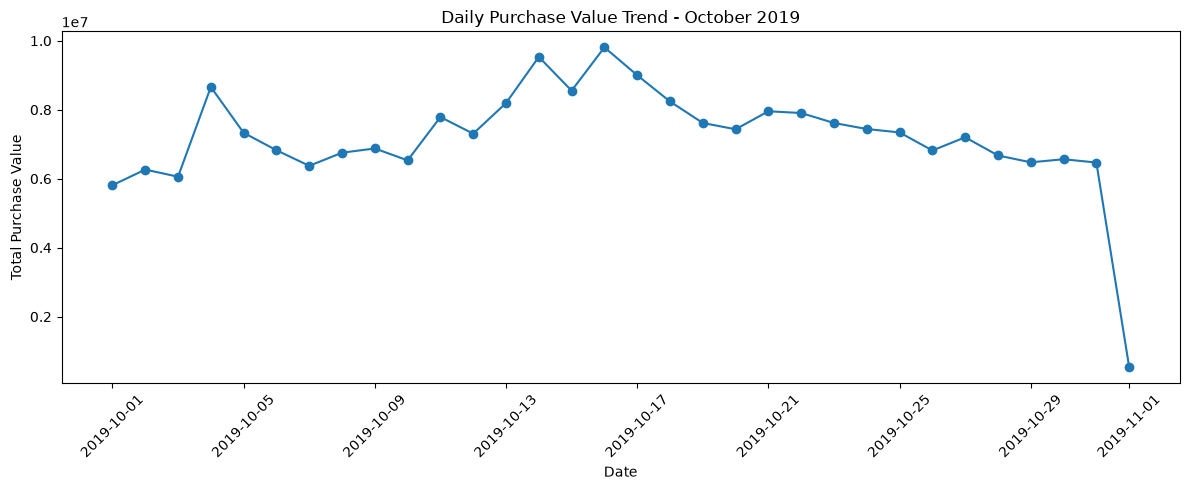

Daily purchase value visualization saved successfully.


In [14]:
import matplotlib.pyplot as plt

daily_sales_pd = daily_sales.toPandas()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales_pd["purchase_date"],
    daily_sales_pd["total_purchase_value"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Total Purchase Value")
plt.title("Daily Purchase Value Trend - October 2019")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/daily_purchase_value_trend_oct.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Daily purchase value visualization saved successfully.")

## Final Analysis Summary

This notebook performed product-level, category-level, brand-level, and time-based sales analysis on the cleaned October 2019 e-commerce dataset.

### Key Results

- Total purchase events: **742,849**
- Purchasing customers: **347,118**
- Unique purchased products: **42,241**
- Unique purchased categories: **567**
- Unique purchased brands: **1,985**
- Total purchase value: approximately **₹229.96 million**
- Average purchase-event value: approximately **₹309.56**

### Product Analysis

Product-level analysis examined:
- Purchase event count
- Number of unique customers
- Total purchase value
- Average purchase value

The analysis identified the highest-value products based on total purchase value and generated a Top-10 product visualization.

### Category Analysis

Category-level analysis examined:
- Purchase events
- Unique products
- Unique customers
- Total purchase value
- Average purchase value

The `electronics.smartphone` category accounted for the largest purchase value in the October dataset.

### Brand Analysis

Brand-level analysis examined:
- Purchase events
- Unique products
- Unique customers
- Total purchase value
- Average purchase value

Among the identified brands, Apple and Samsung accounted for substantial purchase value during October 2019.

### Time-Based Sales Analysis

Daily purchase activity was analyzed across October 2019.

The analysis showed variation in purchase value throughout the month, with the highest daily purchase value occurring on **2019-10-16**, at approximately **₹9.81 million**.

Day-of-week analysis showed that **Wednesday** recorded the highest number of purchase events with **119,201 events**, while **Saturday** recorded the lowest with **96,012 events**.

### Dataset Limitation

The dataset does not contain a country/location attribute. Therefore, country-wise sales analysis was not performed rather than deriving or estimating country information from other fields.

The dataset is also event-level and does not contain an explicit order or transaction ID. Therefore, purchase events are used as the primary unit of sales analysis.